# 📊 AprovaEdu Analytics — Etapa 3: Análises Obrigatórias

Responde às 4 perguntas do desafio a partir da base tratada em `data/final/`
(gerada pelo `notebooks/01_tratamento.ipynb`).

> ### ⚠️ Escopo dos dados: demonstração de método
> Os arquivos disponíveis são **amostras** (máx. 500 linhas/tabela), e cada tabela
> foi truncada de forma independente. Os cruzamentos entre matrícula, presença e
> aprovação — que sustentam as perguntas — têm sobreposição mínima:
>
> | Cruzamento | Alunos |
> |---|---|
> | Aprovados com matrícula na amostra | 18 de 306 |
> | Aprovados com presença na amostra | 18 de 306 |
> | Matrícula **+** presença | 5 |
> | Matrícula **+** aprovação **+** presença | 1 |
>
> **Portanto, os números abaixo demonstram o *método* de análise, não conclusões
> de negócio.** Com a base completa (9.452 matrículas, 21.510 resultados, 74.997
> presenças), o mesmo código produz resultados estatisticamente válidos. Cada seção
> destaca o que mudaria com os dados completos.

## 1. Setup e carga da base tratada

In [1]:
import sys
from pathlib import Path
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
FINAL = ROOT / "data" / "final"

def carregar(nome):
    return pd.read_parquet(FINAL / f"{nome}.parquet")

estudantes = carregar("estudantes"); matriculas = carregar("matriculas")
aprovacoes = carregar("aprovacoes"); presencas = carregar("presencas_aulas")
aulas = carregar("aulas"); resultados = carregar("resultados_sim")
simulados = carregar("simulados"); ofertas = carregar("ofertas_curso")
print("Tabelas carregadas.")

Tabelas carregadas.


### Paleta e estilo dos gráficos
Paleta categórica validada (ordem fixa, colorblind-safe); eixo único, marcas finas,
rótulos diretos, grade recessiva.

In [2]:
PAL = ["#2a78d6", "#1baf7a", "#eda100", "#008300",
       "#4a3aa7", "#e34948", "#e87ba4", "#eb6834"]  # slots categóricos, ordem fixa
BLUE, ORANGE = PAL[0], PAL[7]
INK, INK2, MUTED, GRID, SURF = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#fcfcfb"

plt.rcParams.update({
    "figure.facecolor": SURF, "axes.facecolor": SURF, "savefig.facecolor": SURF,
    "axes.edgecolor": MUTED, "axes.labelcolor": INK2, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED, "font.size": 11,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.dpi": 110, "font.family": "sans-serif",
})

## Q1 — Evolução da taxa de aprovação por ano

**Método.** A taxa de aprovação por ano seria
`aprovados(ano) ÷ base elegível(ano)`. Como *base elegível* usamos os alunos
**distintos matriculados** naquele ano.

Na amostra o denominador está truncado (6–15 matriculados/ano contra 50–80 aprovados),
então a *razão* fica sem sentido. Reportamos, então, dois sinais válidos dentro da
amostra: **o volume de aprovações por ano** e a **nota final média por ano**.

In [3]:
aprov_ano = aprovacoes.groupby("ano_vestibular")["aluno_id"].nunique()
matric_ano = matriculas.groupby("ano")["aluno_id"].nunique()
nota_ano = aprovacoes.groupby("ano_vestibular")["nota_final_vestibular"].mean()

resumo_q1 = pd.DataFrame({
    "aprovados": aprov_ano,
    "matriculados_amostra": matric_ano,
    "nota_final_media": nota_ano.round(1),
})
resumo_q1

,aprovados,matriculados_amostra,nota_final_media
2021,50,9,721.7
2022,53,15,744.6
2023,77,15,703.9
2024,79,12,732.3
2025,80,6,721.2


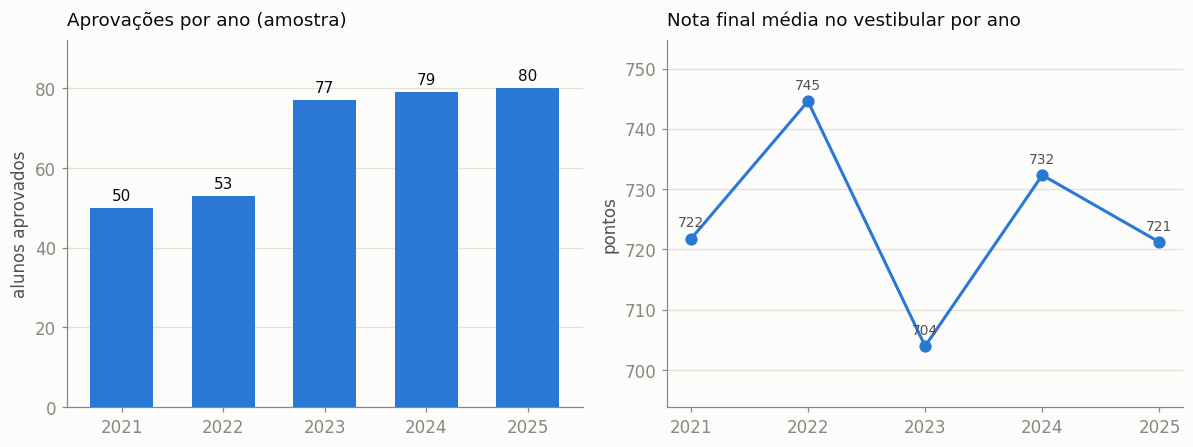

In [4]:
anos = aprov_ano.index.astype(int)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.2))

# (a) aprovações por ano — magnitude por tempo -> barras, hue único
b = a1.bar(anos, aprov_ano.values, color=BLUE, width=0.62, zorder=3)
a1.bar_label(b, padding=3, color=INK, fontsize=10)
a1.set_title("Aprovações por ano (amostra)", color=INK, fontsize=12, loc="left", pad=10)
a1.set_ylabel("alunos aprovados"); a1.set_xticks(anos)
a1.grid(axis="x", visible=False); a1.margins(y=0.15)

# (b) nota final média por ano — mudança no tempo -> linha
a2.plot(anos, nota_ano.values, color=BLUE, lw=2, marker="o", ms=7, zorder=3)
for x, y in zip(anos, nota_ano.values):
    a2.annotate(f"{y:.0f}", (x, y), textcoords="offset points", xytext=(0, 8),
                ha="center", color=INK2, fontsize=9)
a2.set_title("Nota final média no vestibular por ano", color=INK, fontsize=12, loc="left", pad=10)
a2.set_ylabel("pontos"); a2.set_xticks(anos); a2.grid(axis="x", visible=False)
a2.margins(y=0.25)

fig.tight_layout(); plt.show()

**Leitura (na amostra):** o número de aprovações registradas cresce de forma
monotônica (2021→2025), e a nota final média oscila numa faixa estreita (~700–745),
sem tendência clara. *Com a base completa*, a métrica-chave passa a ser a **taxa**
(aprovados ÷ matriculados), que aqui não é confiável pelo truncamento do denominador.

## Q2 — Presença nas aulas × aprovação

**Método.** Para cada aluno, calculamos a **taxa de presença** = (aulas com status
*Presente* ou *Atrasado*) ÷ (registros de presença do aluno). Em seguida comparamos
a taxa média entre quem **foi aprovado** e quem **não foi**.

In [5]:
p = presencas.copy()
p["compareceu"] = p["status_presenca"].isin(["Presente", "Atrasado"])
taxa_presenca = p.groupby("aluno_id")["compareceu"].mean().reset_index(name="taxa_presenca")
taxa_presenca["aprovado"] = taxa_presenca["aluno_id"].isin(set(aprovacoes["aluno_id"]))

resumo_q2 = (taxa_presenca.groupby("aprovado")["taxa_presenca"]
             .agg(media="mean", alunos="count"))
resumo_q2.index = ["Não aprovado", "Aprovado"]
resumo_q2.round(3)

,media,alunos
Não aprovado,0.810,29
Aprovado,0.855,18


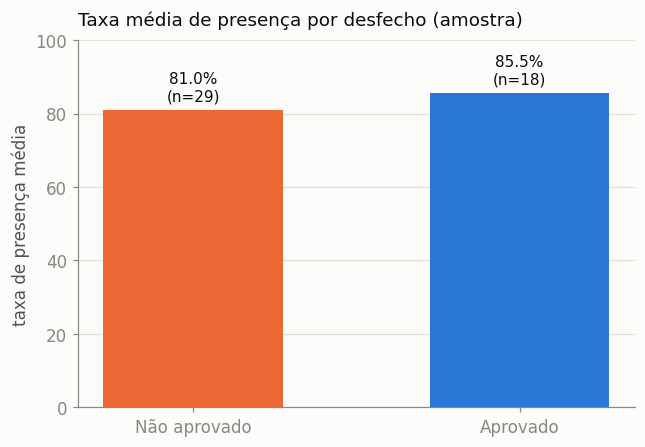

In [6]:
fig, ax = plt.subplots(figsize=(6, 4.2))
cats = ["Não aprovado", "Aprovado"]
vals = (resumo_q2["media"] * 100).values
ns = resumo_q2["alunos"].values
bars = ax.bar(cats, vals, color=[ORANGE, BLUE], width=0.55, zorder=3)
for bar, v, n in zip(bars, vals, ns):
    ax.annotate(f"{v:.1f}%\n(n={n})", (bar.get_x() + bar.get_width()/2, v),
                textcoords="offset points", xytext=(0, 6), ha="center",
                color=INK, fontsize=10)
ax.set_title("Taxa média de presença por desfecho (amostra)", color=INK,
             fontsize=12, loc="left", pad=10)
ax.set_ylabel("taxa de presença média"); ax.grid(axis="x", visible=False)
ax.margins(y=0.18); ax.set_ylim(0, 100)
fig.tight_layout(); plt.show()

**Leitura (na amostra):** a direção é plausível — aprovados apresentam presença
média um pouco maior que não aprovados —, mas com **n=18 vs n=29** e apenas **1 aluno**
com dado completo, isto **não permite afirmar associação**. O método correto na base
completa: taxa de presença por aluno/ano cruzada com o desfecho, testando a associação
(ex.: comparação de médias / correlação ponto-bisserial / regressão logística).

## Q3 — Matérias com melhor desempenho

**Método.** Desempenho = **nota média nos simulados** por matéria (juntando
`resultados_sim` → `simulados.materia`). Reportamos a média e o `n` de provas.

In [7]:
res_mat = resultados.merge(simulados[["simulado_id", "materia"]], on="simulado_id", how="left")
desempenho = (res_mat.dropna(subset=["nota"])
              .groupby("materia")["nota"].agg(media="mean", provas="count")
              .sort_values("media", ascending=False))
desempenho.round(1)

,media,provas
materia,,
Matemática,60.7,362
Física,59.6,94


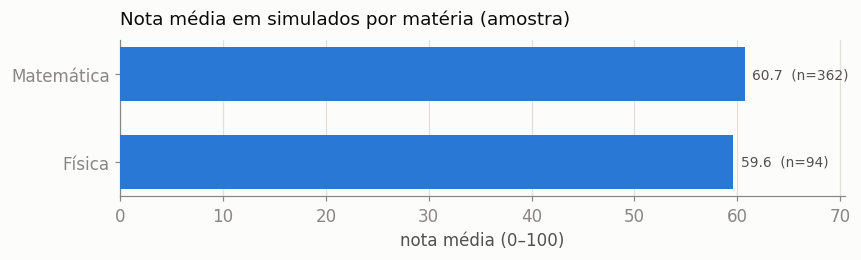

In [8]:
d = desempenho.sort_values("media")  # asc para barh (maior no topo)
fig, ax = plt.subplots(figsize=(8, max(2.5, 0.5 * len(d) + 1.5)))
bars = ax.barh(d.index, d["media"], color=BLUE, height=0.62, zorder=3)
for bar, v, n in zip(bars, d["media"], d["provas"]):
    ax.annotate(f"{v:.1f}  (n={n})", (v, bar.get_y() + bar.get_height()/2),
                textcoords="offset points", xytext=(5, 0), va="center",
                color=INK2, fontsize=9)
ax.set_title("Nota média em simulados por matéria (amostra)", color=INK,
             fontsize=12, loc="left", pad=10)
ax.set_xlabel("nota média (0–100)"); ax.grid(axis="y", visible=False)
ax.margins(x=0.16)
fig.tight_layout(); plt.show()

**Leitura (na amostra):** por truncamento, os resultados cobrem poucas matérias
(concentradas nos primeiros simulados), então o ranking é ilustrativo. *Com a base
completa*, o mesmo agregado cobre todas as matérias e pode ser enriquecido com
dispersão (desvio-padrão), taxa de conclusão de simulados e relação com a aprovação.

## Q4 — Recomendações para a coordenação

As recomendações abaixo derivam do **método** e devem ser confirmadas na base completa.

1. **Monitorar presença como sinal de risco.** A direção observada (aprovados com
   presença maior) justifica acompanhar taxa de presença por aluno/turma e acionar
   alunos com queda de frequência — hipótese a validar com os dados completos.
2. **Priorizar reforço nas matérias de menor nota média** em simulados, realocando
   carga horária e simulados de revisão para as matérias na cauda do ranking.
3. **Padronizar a captura de dados na origem.** O volume de sujeira (datas em 4
   formatos, categorias sem padrão, nomes denormalizados, ~15% de nulos em vários
   campos) indica ganho imediato em qualidade de decisão ao padronizar o cadastro.
4. **Instrumentar a taxa de aprovação por coorte** (ano de ingresso × ano de
   vestibular) para separar efeito de turma, matéria e presença — inviável na amostra,
   direto na base completa.

### O que muda com a base completa
Todo o pipeline (`extract` → `cleaning` → `transform`) e este notebook já rodam
ponta a ponta; basta substituir as amostras pelos CSVs completos em `data/` que as
mesmas células produzem resultados válidos e as conclusões acima podem ser afirmadas
(ou refutadas) com significância.